In [96]:
import polars as pl

from deq.plot import line_plot, grouped_bars
from spells import summon, ColSpec, ColType
from spells.config import all_sets


from great_tables import GT

In [97]:
ext = {
    "has_splash": ColSpec(col_type=ColType.GROUP_BY,
                          expr=pl.when(pl.col("splash_colors").is_null()).then(False).otherwise(True)),
    "deck_lands_gb": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_lands_{name}") for name in names])),
     "deck_spells_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_spells_{name}") for name in names])),
     "deck_mv_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_mana_value_{name}") for name in names])),
     "deck_mv_ratio": ColSpec(col_type=ColType.GROUP_BY, expr=pl.col('deck_mv_hz') / pl.col('deck_spells_hz')),
     "deck_mv_class": ColSpec(col_type=ColType.GROUP_BY, expr=(pl.col("deck_mv_ratio") * 4).round() / 4)
}


In [113]:
set_code="FIN"

game_wr = (pl.col('num_won')/pl.col('num_games')).alias('game_wr')
df = summon(
    set_code,
    ["num_won", "num_games"],
    group_by=["deck_lands_gb", "deck_mv_class"],
    extensions=ext, 
    filter_spec={
        '$and':[
            {'lhs': 'num_colors', 'op': '<=', 'rhs': 2},
            #{'main_colors': 'WR'},
            {'player_cohort': 'Top'},
            {"lhs": "format_day", "op":">=", "rhs": 1},
        ]
    }
).sort('num_games', descending=True)

df = df.with_columns(game_wr)


In [114]:
group_df = df.drop('deck_mv_class').group_by('deck_lands_gb').sum()
group_df = group_df.with_columns(game_wr).drop('num_won')


In [115]:
pivot = df.filter(  
    pl.col('num_games') > 1000).pivot(   
    on="deck_lands_gb", 
    index="deck_mv_class", 
    values="game_wr").sort(
    "deck_mv_class").rename(
    {'deck_mv_class': 'Deck Average Mana Value'})



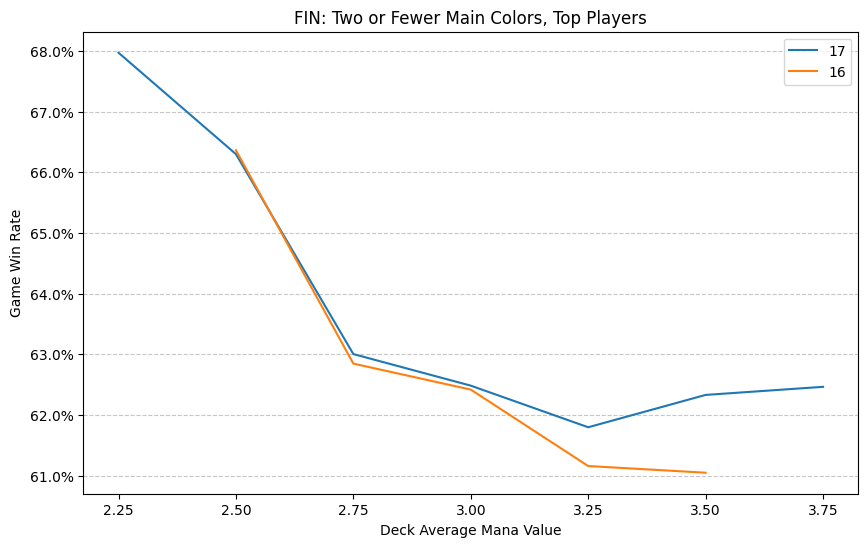

In [116]:
line_plot(
    pivot, 
    title=f"{set_code}: Two or Fewer Main Colors, Top Players",
    is_pct=True,
    y_label="Game Win Rate"
)


In [91]:
df = summon(
    "OTJ", 
    ["game_wr", "num_games"],
    group_by=["deck_lands_gb"],
    extensions=ext, 
    filter_spec={
        '$and':[
            {'lhs': 'num_colors', 'op': '<=', 'rhs': 5},
            {"player_cohort": "Top"},
            {"lhs": "format_day", "op":">", "rhs": 6}
        ]
    }
).sort('num_games', descending=True)


In [94]:
GT(df.with_columns(game_wr).drop("num_won")
   .sort("deck_lands_gb").filter(pl.col('num_games') > 100).rename(
    {'deck_lands_gb': 'Num Lands', "has_splash":"Splash", 'game_wr': 'Game WR', 'num_games': 'Num Games'}
)).fmt_percent(columns="Game WR").tab_header(
    title="Boros", subtitle="Win Rate by Number of Lands in Deck, Top Players")




GT(_tbl_data=shape: (6, 4)
┌───────────┬────────┬───────────┬──────────┐
│ Num Lands ┆ Splash ┆ Num Games ┆ Game WR  │
│ ---       ┆ ---    ┆ ---       ┆ ---      │
│ i8        ┆ bool   ┆ u32       ┆ f64      │
╞═══════════╪════════╪═══════════╪══════════╡
│ 15        ┆ false  ┆ 186       ┆ 0.688172 │
│ 15        ┆ true   ┆ 127       ┆ 0.685039 │
│ 16        ┆ true   ┆ 1344      ┆ 0.648065 │
│ 16        ┆ false  ┆ 902       ┆ 0.665188 │
│ 17        ┆ true   ┆ 1577      ┆ 0.63475  │
│ 17        ┆ false  ┆ 578       ┆ 0.650519 │
└───────────┴────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x7f8705828cd0>, _boxhead=Boxhead([ColInfo(var='Num Lands', type=<ColInfoTypeEnum.default: 1>, column_label='Num Lands', column_align='right', column_width=None), ColInfo(var='Splash', type=<ColInfoTypeEnum.default: 1>, column_label='Splash', column_align='center', column_width=None), ColInfo(var='Num Games', type=<ColInfoTypeEnum.default: 1>, column_label='Num Games', column_align='center', column_width=None), ColInfo(var='Game WR', type=<ColInfoTypeEnum.default: 1>, column_label='Game WR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f8705709dd0>, _spanners=Spanners([]), _heading=Heading(title='Boros', subtitle='Win Rate by Number of Lands in Deck, Top Players', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f870570a150>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f87057094d0>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value